In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as Hung

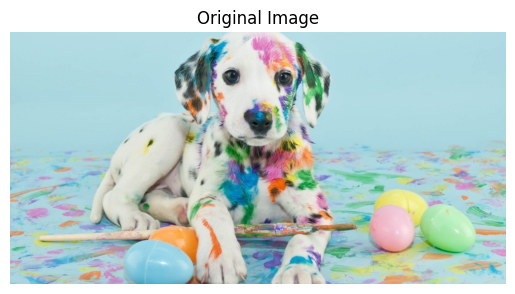

In [3]:
img = cv.imread('hinh1.jpg')
img2 = cv.imread('hinh2.jpg')

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

Hung.imshow(img_rgb)
Hung.title("Original Image")
Hung.axis('off')
Hung.show()

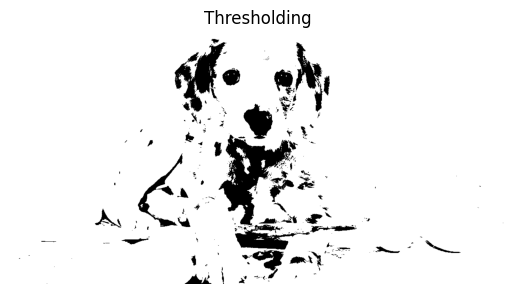

In [5]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

_, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

Hung.imshow(thresh, cmap='gray')
Hung.title("Thresholding")
Hung.axis('off')
Hung.show()

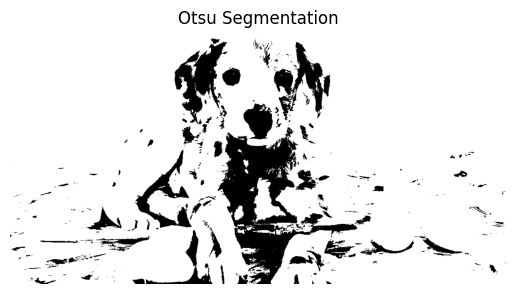

In [6]:
_, otsu = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

Hung.imshow(otsu, cmap='gray')
Hung.title("Otsu Segmentation")
Hung.axis('off')
Hung.show()

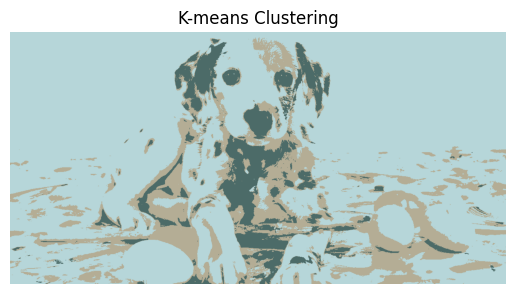

In [7]:
Z = img.reshape((-1,3))
Z = np.float32(Z)

K = 3
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

_, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img.shape))

res2_rgb = cv.cvtColor(res2, cv.COLOR_BGR2RGB)

Hung.imshow(res2_rgb)
Hung.title("K-means Clustering")
Hung.axis('off')
Hung.show()

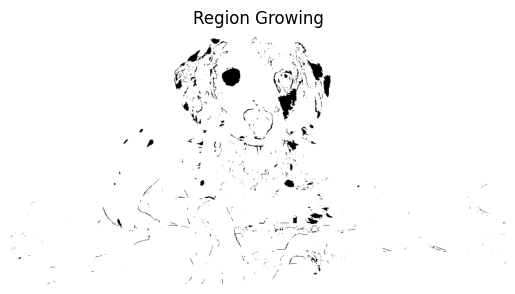

In [8]:
def region_growing(img, seed):
    h, w = img.shape
    segmented = np.zeros((h, w), np.uint8)

    stack = [seed]
    threshold = 10

    while stack:
        x, y = stack.pop()
        if segmented[x, y] == 0:
            segmented[x, y] = 255

            for dx in [-1, 0, 1]:
                for dy in [-1, 0, 1]:
                    nx, ny = x + dx, y + dy

                    if 0 <= nx < h and 0 <= ny < w:
                        if abs(int(img[nx, ny]) - int(img[x, y])) < threshold:
                            stack.append((nx, ny))

    return segmented

seed_point = (100, 100)
region = region_growing(gray, seed_point)

Hung.imshow(region, cmap='gray')
Hung.title("Region Growing")
Hung.axis('off')
Hung.show()

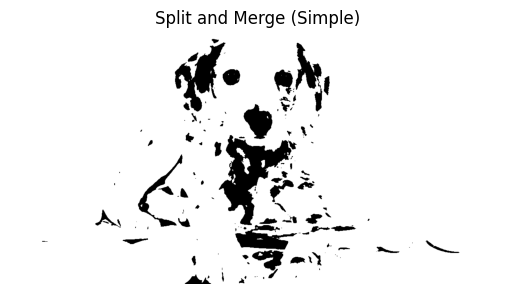

In [9]:
blur = cv.GaussianBlur(gray, (5,5), 0)
_, split_merge = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)

Hung.imshow(split_merge, cmap='gray')
Hung.title("Split and Merge (Simple)")
Hung.axis('off')
Hung.show()

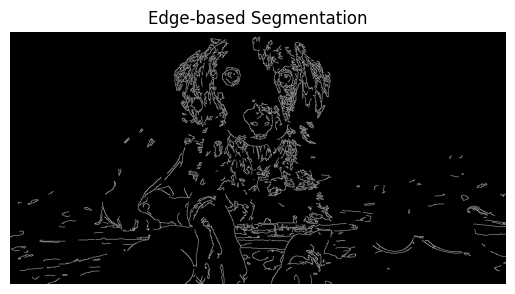

In [10]:
edges = cv.Canny(gray, 100, 200)

Hung.imshow(edges, cmap='gray')
Hung.title("Edge-based Segmentation")
Hung.axis('off')
Hung.show()